# Parte 2: Auditoria do Modelo em Produção

## Desempenho com Incerteza e Análise de Falhas

**Objetivo**: Avaliar o desempenho global do modelo A com rigor estatístico, e investigar onde e por que o modelo falha, identificando padrões nos erros que impactam o encaminhamento dos chamados.

## Setup

In [10]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
from sklearn.metrics import balanced_accuracy_score


DADOS_PATH = Path('../dados/chamados_com_predicoes.csv')
FIGURES_PATH = Path('../results/figures/')

## 2. Desempenho com Incerteza

In [19]:
df = pd.read_csv(DADOS_PATH, encoding='utf-8')

y_true = df['categoria_real']
y_pred = df['pred_modelo_a']
classes = sorted(df['categoria_real'].unique())

In [32]:
RANDOM_STATE = 42
N_BOOTSTRAP = 1000

def bootstrap_ic(y_true, y_pred, metric_fn, n_bootstrap=N_BOOTSTRAP, ic=95, random_state=RANDOM_STATE):
    """
    Calcula valor observado e IC via bootstrap para uma métrica.
    """
    y_true = pd.Series(y_true).reset_index(drop=True)
    y_pred = pd.Series(y_pred).reset_index(drop=True)
    
    rng = np.random.default_rng(random_state)
    n = len(y_true)
    indices = np.arange(n)
    
    observed = metric_fn(y_true, y_pred)
    boot_values = []
    
    for _ in range(n_bootstrap):
        idx = rng.choice(indices, size=n, replace=True)
        boot_values.append(metric_fn(y_true.iloc[idx], y_pred.iloc[idx]))
    
    lower = np.percentile(boot_values, (100 - ic) / 2)
    upper = np.percentile(boot_values, 100 - (100 - ic) / 2)
    
    return observed, boot_values, lower, upper

In [34]:
def macro_f1(y_true, y_pred):
    return f1_score(y_true, y_pred, average='macro', zero_division=0)

def weighted_f1(y_true, y_pred):
    return f1_score(y_true, y_pred, average='weighted', zero_division=0)

metrics_global = [
    ('Acurácia', accuracy_score),
    ('Balanced Accuracy', balanced_accuracy_score),
    ('F1 Macro', macro_f1),
    ('F1 Weighted', weighted_f1)
]

results_global = []
bootstrap_distributions = {}

for name, fn in metrics_global:
    observed, boots_values, low, high = bootstrap_ic(y_true, y_pred, fn)
    results_global.append({
        'Métrica': name,
        'Valor observado': observed,
        'IC 95% - inferior': low,
        'IC 95% - superior': high,
        'IC 95%': f'[{low:.3f}, {high:.3f}]'
    })
    bootstrap_distributions[name] = np.asarray(boots_values)

metrics_global_df = pd.DataFrame(results_global)
metrics_global_df[['Métrica', 'Valor observado', 'IC 95%']] \
    .style.format({'Valor observado': '{:.3f}'})

,Métrica,Valor observado,IC 95%
0,Acurácia,0.773,"[0.761, 0.784]"
1,Balanced Accuracy,0.771,"[0.757, 0.784]"
2,F1 Macro,0.770,"[0.757, 0.782]"
3,F1 Weighted,0.773,"[0.760, 0.784]"


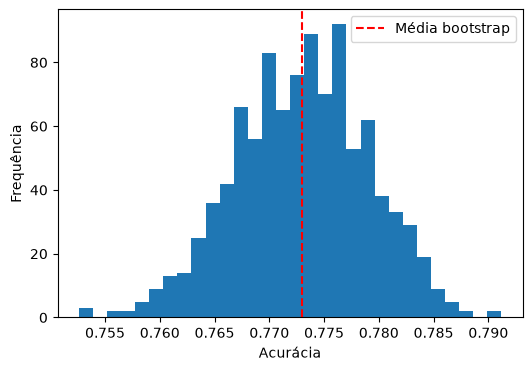

In [35]:
values = bootstrap_distributions["Acurácia"]

plt.figure(figsize=(6,4))
plt.hist(values, bins=30)
plt.axvline(values.mean(), color="red", linestyle="--", label="Média bootstrap")
plt.legend()
plt.xlabel("Acurácia")
plt.ylabel("Frequência")
plt.show()